In [33]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [34]:
def find_project_root(start=Path.cwd()):
    """
    Walk upward until we find a project root marker.
    """
    markers = [".git", "pyproject.toml", "setup.py"]

    current = start.resolve()

    while current != current.parent:
        for marker in markers:
            if (current / marker).exists():
                return current
        current = current.parent

    raise RuntimeError("Project root not found")


PROJECT_ROOT = str(find_project_root())
# print(str(PROJECT_ROOT))
# --- System matrices (SI units) ---
M = np.array([[215.0, -20.0],
              [-20.0, 150.0]], dtype=float)

C = np.array([[2000.0,    0.0],
              [   0.0, 1000.0]], dtype=float)

K = np.array([[4.21e6,   0.0],
              [  0.0, 4.61e6]], dtype=float)

def load_macro_from_npz(npz_path, axes=(0, 1)):
    data = np.load(npz_path, allow_pickle=False)

    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes

    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]

    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras

M2, C2, K2, extras = load_macro_from_npz(PROJECT_ROOT + "/data/linearized_operational_space_xyz.npz", axes=(0, 1))  # (x,y)
M = M2
C = C2
K = K2


# --- Attached mass (not used in G(s) yet) ---
M_micro = np.diag([100.0, 100.0])  # kg

Z = np.zeros((2,2))
I = np.eye(2)
Minv = np.linalg.inv(M + M_micro)

A = np.block([
    [Z, I],
    [-Minv @ K, -Minv @ C]
])

eigvals = np.linalg.eigvals(A)


In [35]:
def G_of_s(s: complex, M: np.ndarray, C: np.ndarray, K: np.ndarray) -> np.ndarray:
    """Return G(s) = (s^2 M + s C + K)^(-1) for a 2x2 system."""
    D = (s**2)*M + s*C + K
    return np.linalg.inv(D)

def freq_response(M, C, K, w):
    """
    Compute G(jw) over frequency grid w (rad/s).
    Returns: Gjw with shape (len(w), 2, 2)
    """
    Gjw = np.zeros((len(w), 2, 2), dtype=complex)
    for i, wi in enumerate(w):
        s = 1j * wi
        Gjw[i] = G_of_s(s, M, C, K)
    return Gjw

def ss_2_freqResp(A, B, C, D, w):
    """
    Frequency response of state-space system:
      G(jw) = C (jwI - A)^(-1) B + D
    Returns Gjw with shape (len(w), ny, nu)
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)
    D = np.asarray(D, dtype=float)

    n = A.shape[0]
    ny = C.shape[0]
    nu = B.shape[1]

    Gjw = np.zeros((len(w), ny, nu), dtype=complex)
    I = np.eye(n)

    for k, wi in enumerate(w):
        sI_minus_A = 1j * wi * I - A
        # Solve (jwI - A) X = B  => X = (jwI - A)^(-1) B
        X = np.linalg.solve(sI_minus_A, B)
        Gjw[k] = C @ X + D
    return Gjw



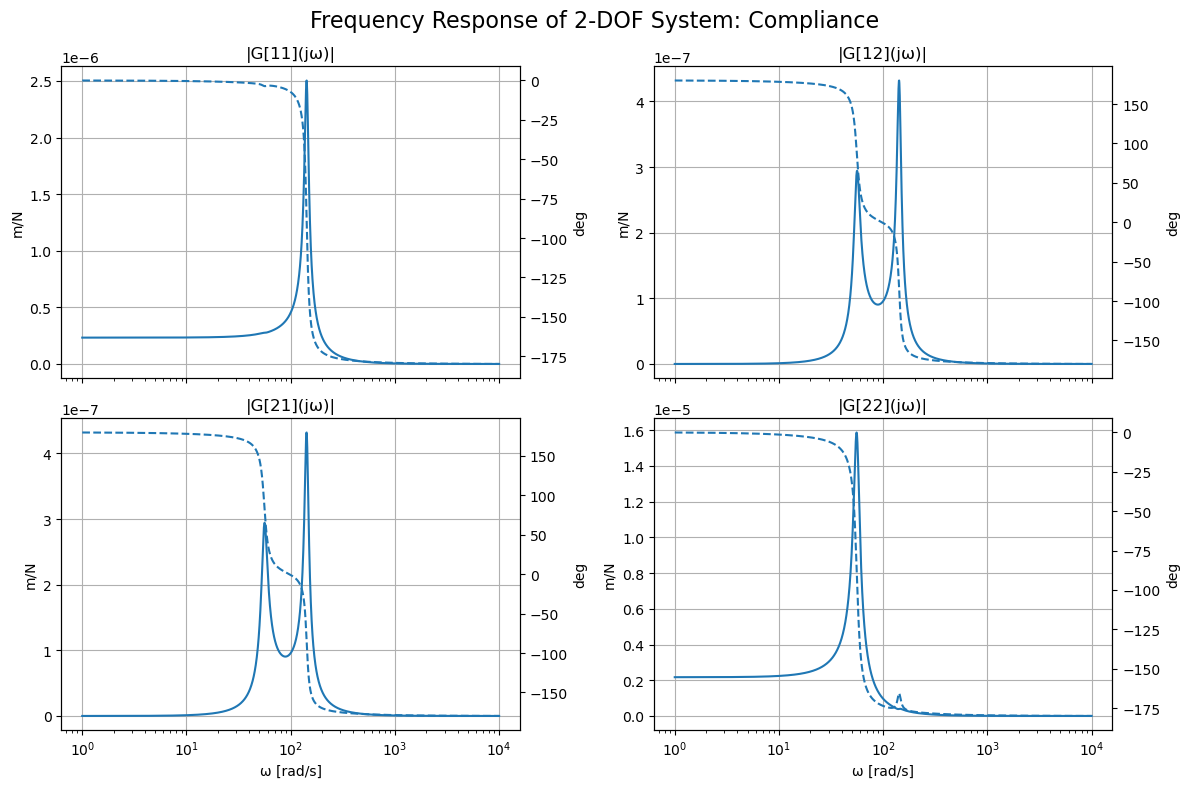

In [36]:

w = np.logspace(0, 4, 2000)  # rad/s
Gjw = freq_response(M, C, K, w)  # shape: (N, 2, 2)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

fig.suptitle("Frequency Response of 2-DOF System: Compliance", fontsize=16)
for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):
    ax = axes[idx]
    ax.grid(True)
    Hij = Gjw[:, i, j]
    mag = np.abs(Hij)  # m/N
    phase = np.unwrap(np.angle(Hij)) * 180/np.pi

    ax.semilogx(w, mag)
    ax.set_title(f"|G[{i+1}{j+1}](jω)|")
    ax.set_ylabel("m/N")
    ax2 = ax.twinx()
    ax2.semilogx(w, phase, linestyle="--")
    ax2.set_ylabel("deg")

axes[-1].set_xlabel("ω [rad/s]")
axes[-2].set_xlabel("ω [rad/s]")

plt.tight_layout()
plt.show()




Mode | sigma [1/s] | wd [rad/s] | fd [Hz] | wn [rad/s] | zeta [-]
   1 |     -2.279 |     43.074 |    6.855 |    43.135 |  0.0528
   2 |     -4.436 |    117.005 |   18.622 |   117.090 |  0.0379


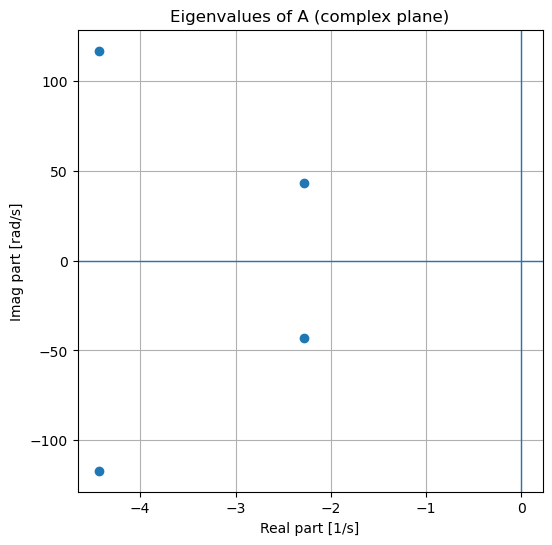

Stable (all Re(lambda) < 0): True
Max real part: -2.2794152004335393


In [37]:
# Keep only eigenvalues with positive imaginary part (one per complex pair)
pos = eigvals[eigvals.imag > 1e-9]

# Sort by damped frequency
pos = pos[np.argsort(pos.imag)]

sigma = pos.real
wd = pos.imag                      # rad/s
fd = wd / (2*np.pi)                # Hz
wn = np.sqrt(sigma**2 + wd**2)      # rad/s (undamped natural freq estimate)
zeta = -sigma / wn                 # damping ratio

print("Mode | sigma [1/s] | wd [rad/s] | fd [Hz] | wn [rad/s] | zeta [-]")
for k, (s, wdi, fdi, wni, zi) in enumerate(zip(sigma, wd, fd, wn, zeta), start=1):
    print(f"{k:>4d} | {s:>10.3f} | {wdi:>10.3f} | {fdi:>8.3f} | {wni:>9.3f} | {zi:>7.4f}")


# --- Plot eigenvalues ---
plt.figure(figsize=(6,6))
plt.scatter(eigvals.real, eigvals.imag)

# axes lines
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real part [1/s]")
plt.ylabel("Imag part [rad/s]")
plt.title("Eigenvalues of A (complex plane)")
plt.grid(True)
# plt.axis('equal')
plt.show()

stable = np.all(eigvals.real < 0)
print("Stable (all Re(lambda) < 0):", stable)
print("Max real part:", eigvals.real.max())


In [38]:
# State: z = [x(2); x_hat(2); xdot(2); xhatdot(2)]  -> dimension 8
I = np.eye(2)
Z = np.zeros((2, 2))

Minv = np.linalg.inv(M)
Mmic_inv = np.linalg.inv(M_micro)

A = np.zeros((8, 8))
Bu = np.zeros((8, 2))

nu = 5_000.0  # N*s/m
Bv = nu * np.eye(2)  # viscous coupling matrix (2x2)
G  = np.zeros((8,2))       # milling/process force input matrix

A[0:2, 4:6] = I
A[2:4, 6:8] = I
A[4:6, 0:2] = -Minv @ K
A[4:6, 4:6] = -Minv @ (C + Bv)
A[4:6, 6:8] =  Minv @ Bv
Bu[4:6, :]  =  Minv             # +u on structure

# vhatdot = xhatddot = Mmic^-1( -Bv(vhat - v) - u )
A[6:8, 4:6] =  Mmic_inv @ Bv
A[6:8, 6:8] = -Mmic_inv @ Bv
Bu[6:8, :]  = -Mmic_inv # -u on micro mass
G [6:8, :]  =  Mmic_inv # For process forces acting on micro mass (e.g. cutting forces)


eigvals = np.linalg.eigvals(A)
print(eigvals)
print("max Re(lambda) =", np.max(eigvals.real))


[  0.          +0.j           0.          +0.j
 -17.11158896+137.12785496j -17.11158896-137.12785496j
  -9.32813951 +45.33985168j  -9.32813951 -45.33985168j
 -72.93103559  +0.j         -52.94698993  +0.j        ]
max Re(lambda) = 0.0


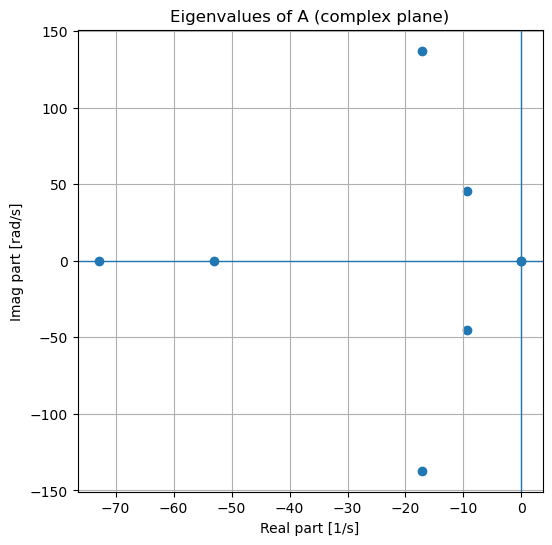

Stable (all Re(lambda) < 0): False
Max real part: 0.0


In [39]:
# --- Plot eigenvalues of LTI system: Full Plant P(s)---
plt.figure(figsize=(6,6))
plt.scatter(eigvals.real, eigvals.imag)

# axes lines
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real part [1/s]")
plt.ylabel("Imag part [rad/s]")
plt.title("Eigenvalues of A (complex plane)")
plt.grid(True)
# plt.axis('equal')
plt.show()

stable = np.all(eigvals.real < 0)
print("Stable (all Re(lambda) < 0):", stable)
print("Max real part:", eigvals.real.max())

In [40]:
# ---- Process stiffness design ----


# Entry and exit Angles for downmilling
def compute_entry_exit_angles_downmilling_steady(b: float, D: float):
    # Current tool entry / exit angles: --> https://www.sciencedirect.com/science/article/pii/S0888327020307044#b0160
    arg = np.clip(1.0 - (2.0 * b / D), -1.0, 1.0)
    phi_st = np.pi - np.arccos(arg)
    phi_ex = np.pi
    return phi_st, phi_ex

# Gradient average cutting force steady state 
def zero_order_dF(
    c: float,
    a_axial: float,
    b_radial: float,
    D: float,
    N_teeth: float,
    phi_st: float,
    phi_ex: float,
    n_hat: np.ndarray,
    Ktc: float,
    Krc: float
):
    nx, ny = n_hat
    tx, ty = -ny, nx
    v = 0.0  # full entry assumption

    dphi_st_db = -1.0 / np.sqrt(b_radial * (D - b_radial))
    dphi_ex_dv = -2.0 / np.sqrt(D**2 - 4*v**2)

    def q(phi):
        h = c * np.sin(phi)
        T = np.array([[-np.cos(phi), -np.sin(phi)],
                      [ np.sin(phi), -np.cos(phi)]])
        K = np.array([Ktc, Krc])
        return a_axial * (T @ K) * h

    dF_dv = N_teeth/(2*np.pi) * q(phi_ex) * dphi_ex_dv
    dF_db = N_teeth/(2*np.pi) * (-q(phi_st) * dphi_st_db)

    dF_dx = dF_db * (-nx) + dF_dv * (-tx)
    dF_dy = dF_db * (-ny) + dF_dv * (-ty)

    return np.column_stack((dF_dx, dF_dy))

def zero_order_force(
                                c: float,  
                                a: float, 
                                N: float, 
                                phi_st: float, 
                                phi_ex: float, 
                                Ktc: float, 
                                Krc: float,
                                Kte: float = 0.0,
                                Kre: float = 0.0):
    
    # # Downmilling start/exit angles (Eq. 8)
    ax1_func = lambda phi: ( Ktc*np.cos(2*phi) - Krc*(2*phi - np.sin(2*phi)))
    ay1_func = lambda phi: ( Ktc*(2*phi - np.sin(2*phi) )+ Krc*np.cos(2*phi)) 
    ax0_func = lambda phi: ( -Kte*np.sin(phi) + Kre*np.cos(phi) ) 
    ay0_func = lambda phi: ( Kte*np.cos(phi) + Kre*np.sin(phi) )
    
    ax1 = (N*a)/ (8*np.pi) *  ( ax1_func(phi_ex) - ax1_func(phi_st) )
    ax0 = (N*a)/ (2*np.pi) *  ( ax0_func(phi_ex) + ax0_func(phi_st) )
    ay1 = (N*a)/ (8*np.pi) *  ( ay1_func(phi_ex) - ay1_func(phi_st) )
    ay0 = -(N*a)/ (2*np.pi) * ( ay0_func(phi_ex) + ay0_func(phi_st) )
    
    Fx0 = ax1*c + ax0
    Fy0 = ay1*c + ay0

    return np.array([Fx0, Fy0], dtype=float)

def A0(
                                phi_st: float, 
                                phi_ex: float,  
                                Kr: float,
                                ):
    
    # Averaged directional Force matrix as defined by Yusuf Altintas
    axx_func = lambda phi: ( np.cos(2*phi)  - 2*Kr*phi + Kr* np.sin(2*phi))* 0.5
    axy_func = lambda phi: ( -np.sin(2*phi) - 2*phi   + Kr *np.cos(2*phi)) * 0.5
    ayx_func = lambda phi: ( -np.sin(2*phi) + 2*phi   + Kr *np.cos(2*phi)) * 0.5
    ayy_func = lambda phi: ( -np.cos(2*phi) - 2*Kr*phi - Kr*np.sin(2*phi)) * 0.5
    
    return np.array([  
        [axx_func(phi_ex) - axx_func(phi_st), axy_func(phi_ex) - axy_func(phi_st)],
        [ayx_func(phi_ex) - ayx_func(phi_st), ayy_func(phi_ex) - ayy_func(phi_st)]
    ])


def get_K_eff(K1, K2):
    return K1 + K2

In [41]:
# Milling parameters

Ktc = 1930.4 # N/mm
Krc = 1159.6 # N/mm
Kt = Ktc # N/mm
Kr = Krc / Ktc # N/mm

axial_depth = 2.0 # mm
radial_depth = 10.0 # mm

D = 20.0 # mm
N_teeth = 8
rpm = 8000.0 # rpm
fz = 0.18 #0.18 # mm/tooth

phi_st , phi_ex = compute_entry_exit_angles_downmilling_steady(radial_depth, D)
K_gradient = zero_order_dF(
                            c=fz,
                            a_axial=axial_depth,
                            b_radial=radial_depth,
                            D=D,
                            N_teeth=N_teeth,
                            phi_st=phi_st,
                            phi_ex=phi_ex,
                            n_hat=np.array([0.0 , 1.0]),  # normal vector pointing in y direction - Top Edge
                            Ktc=Ktc,
                            Krc=Krc
                        )

K_p = K_gradient * 1e3 # convert to N/m

A_0 = A0(phi_st, phi_ex, Kr)

print("\n K_gradient (N/mm):", K_gradient)
print("\n A_0 (N/mm):", A_0)
print("\n A_0 * Kt * 0.5 (N/mm):", A_0 * Kt * 0.5)



 K_gradient (N/mm): [[-1.08360445e-14  5.31521487e+01]
 [-6.50926088e-15 -8.84830182e+01]]

 A_0 (N/mm): [[ 0.05641555 -0.97009181]
 [ 2.17150084 -1.94358445]]

 A_0 * Kt * 0.5 (N/mm): [[   54.45228972  -936.33261462]
 [ 2095.93261462 -1875.94771028]]


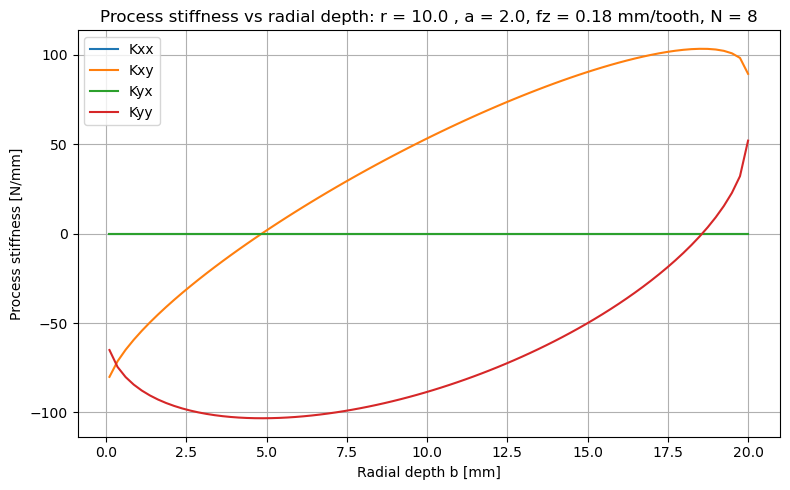

In [42]:
# --- sweep radial depth from near 0 to D ---
b_vals = np.linspace(0.1, D-1e-3, 80)   # mm (avoid exactly zero)

Kxx, Kxy, Kyx, Kyy = [], [], [], []

for b in b_vals:
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(b, D)

    Kg = zero_order_dF(
        c=fz,
        a_axial=axial_depth,
        b_radial=b,
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )

    Kp_tmp = Kg #* 1e3   # convert to N/m

    Kxx.append(Kp_tmp[0,0])
    Kxy.append(Kp_tmp[0,1])
    Kyx.append(Kp_tmp[1,0])
    Kyy.append(Kp_tmp[1,1])

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(b_vals, Kxx, label="Kxx")
plt.plot(b_vals, Kxy, label="Kxy")
plt.plot(b_vals, Kyx, label="Kyx")
plt.plot(b_vals, Kyy, label="Kyy")

plt.xlabel("Radial depth b [mm]")
plt.ylabel("Process stiffness [N/mm]")
plt.title(f"Process stiffness vs radial depth: r = {radial_depth} , a = {axial_depth}, fz = {fz} mm/tooth, N = {N_teeth}")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [43]:
# Model which includes process stiffness

# --- selector: xhat = H z ---
H = np.zeros((2,8))
H[:, 2:4] = np.eye(2)

K_p = np.asarray(K_p, dtype=float)

A_proc = A + G @ (-K_p) @ H # Adjusted state matrix which now includes stiffness


In [44]:
def Rtheta(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def rotate_Kp(J_local, theta):
    R = Rtheta(theta)
    return R @ J_local @ R.T

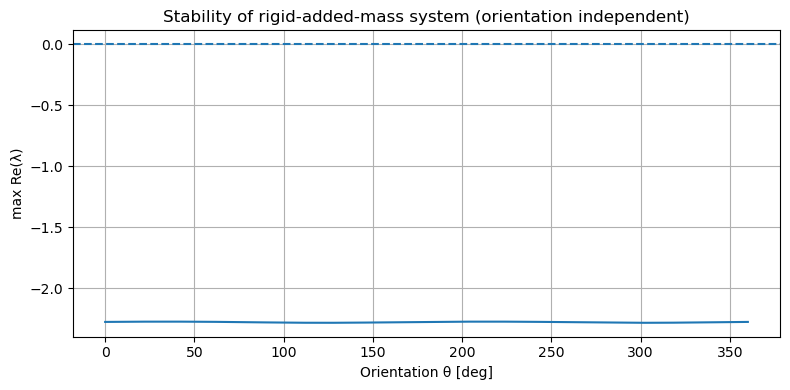

In [45]:

M_hat_tot = M + M_micro
M_hat_inv = np.linalg.inv(M_hat_tot)

I = np.eye(2)
Z = np.zeros((2,2))

# --- state matrix (z = [x; xdot]) ---
A_mass = np.block([
    [Z, I],
    [-M_hat_inv @ K, -M_hat_inv @ C]
])

# --- orientation sweep ----
theta_deg = np.arange(0, 360+2, 2)   # include 360
theta_rad = np.deg2rad(theta_deg)

Kp_list = []
A_list  = []
eig_list = []
max_real = []

for th in theta_rad:
    Kp_rot = rotate_Kp(K_p, th)
    Kp_list.append(Kp_rot)

    K_eff = get_K_eff(K, Kp_rot)

    A_theta = np.block([
        [Z, I],
        [-M_hat_inv @ K_eff, -M_hat_inv @ C]
    ])

    A_list.append(A_theta)

    eigvals = np.linalg.eigvals(A_theta)
    eig_list.append(eigvals)
    max_real.append(np.max(eigvals.real))

max_real = np.array(max_real)

max_real = np.array(max_real)

plt.figure(figsize=(8,4))
plt.plot(theta_deg, max_real)
plt.axhline(0, linestyle='--')

plt.xlabel("Orientation θ [deg]")
plt.ylabel("max Re(λ)")
plt.title("Stability of rigid-added-mass system (orientation independent)")
plt.grid(True)

plt.tight_layout()
plt.show()


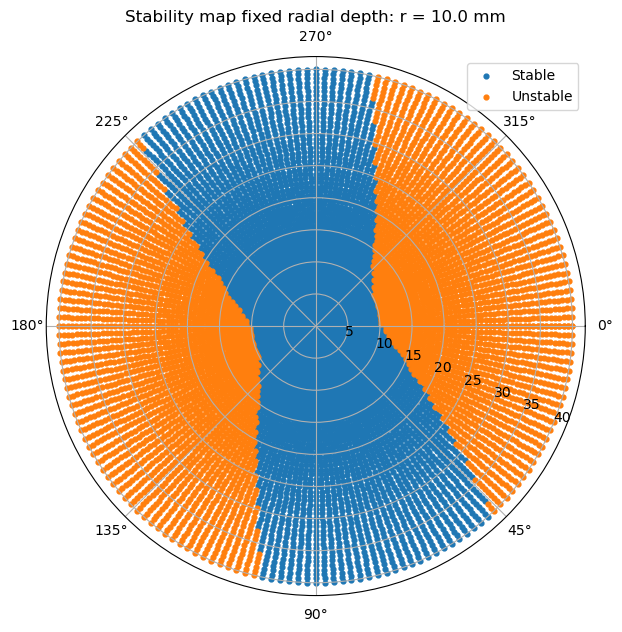

In [46]:

a_max = 40.0
a_depth_vals = np.linspace(0.1, a_max, 60)          # mm (avoid exactly 0)
max_real_map = np.zeros((len(a_depth_vals), len(theta_rad)))

# --- compute map ---
for ia, a_depth in enumerate(a_depth_vals):

    # entry/exit angles for downmilling at this radial depth
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(radial_depth, D)

    # base (unrotated) process stiffness at this depth
    Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth, 
        b_radial=radial_depth,   
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )
    Kp_base = Kg * 1e3  # N/m

    for it, th in enumerate(theta_rad):
        Kp_rot = rotate_Kp(Kp_base, th)
        K_eff = get_K_eff(K, Kp_rot)

        A_theta = np.block([
            [Z, I],
            [-M_hat_inv @ K_eff, -M_hat_inv @ C]
        ])

        eigvals = np.linalg.eigvals(A_theta)
        max_real_map[ia, it] = np.max(eigvals.real)
        

theta_step = 1     
depth_step = 1    

theta_sub = theta_rad[::theta_step]
depth_sub = a_depth_vals[::depth_step]

stable_theta = []
stable_r = []

unstable_theta = []
unstable_r = []

for i_d, a_depth in enumerate(depth_sub):
    for i_t, th in enumerate(theta_sub):

        # map back to original indices
        orig_d = i_d * depth_step
        orig_t = i_t * theta_step

        val = max_real_map[orig_d, orig_t]

        if val < 0:
            stable_theta.append(th)
            stable_r.append(a_depth)
        else:
            unstable_theta.append(th)
            unstable_r.append(a_depth)
            
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

ax.scatter(stable_theta, stable_r, s=12, label="Stable")
ax.scatter(unstable_theta, unstable_r, s=12, label="Unstable")

ax.set_title("Stability map fixed radial depth: r = {:.1f} mm".format(radial_depth))
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

ax.legend(loc="upper right")
plt.show()


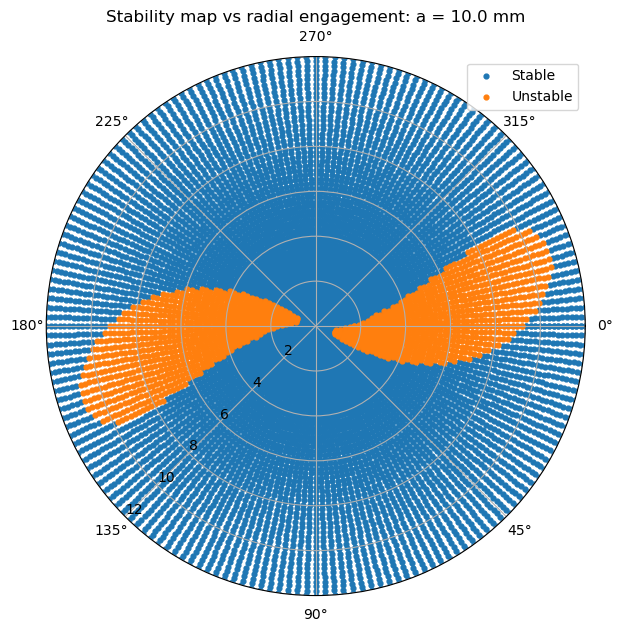

In [47]:
a_depth = 10.0 # mm
r_max = D/2+2
r_depth_vals = np.linspace(0.1, r_max, 60)          # mm (avoid exactly 0)
max_real_map = np.zeros((len(r_depth_vals), len(theta_rad)))

# --- compute map ---
for ia, r_depth in enumerate(r_depth_vals):

    # entry/exit angles for downmilling at this radial depth
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(r_depth, D)

    # base (unrotated) process stiffness at this depth
    Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth, 
        b_radial=r_depth,   
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )
    Kp_base = Kg * 1e3  # N/m

    for it, th in enumerate(theta_rad):
        Kp_rot = rotate_Kp(Kp_base, th)
        K_eff = get_K_eff(K, Kp_rot)

        A_theta = np.block([
            [Z, I],
            [-M_hat_inv @ K_eff, -M_hat_inv @ C]
        ])

        eigvals = np.linalg.eigvals(A_theta)
        max_real_map[ia, it] = np.max(eigvals.real)
        
theta_step = 1
depth_step = 1

theta_sub = theta_rad[::theta_step]
depth_sub = r_depth_vals[::depth_step]

stable_theta, stable_r = [], []
unstable_theta, unstable_r = [], []

for i_d, r_depth in enumerate(depth_sub):
    for i_t, th in enumerate(theta_sub):

        orig_d = i_d * depth_step
        orig_t = i_t * theta_step

        val = max_real_map[orig_d, orig_t]

        if val < 0:
            stable_theta.append(th)
            stable_r.append(r_depth)      # <-- FIX: use radial engagement
        else:
            unstable_theta.append(th)
            unstable_r.append(r_depth)    # <-- FIX: use radial engagement

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

ax.scatter(stable_theta, stable_r, s=12, label="Stable")
ax.scatter(unstable_theta, unstable_r, s=12, label="Unstable")

ax.set_title(f"Stability map vs radial engagement: a = {a_depth} mm")
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

ax.set_rlabel_position(135)
ax.set_rlim(0, r_max)  

ax.legend(loc="upper right")
plt.show()

In [48]:
def build_second_order_ss(M, C, K):
    """
    Convert: M xdd + C xd + K x = 0  (n=2)  to
    z = [x; xd] in R^4,   zdot = A z
    """
    I = np.eye(2)
    Z = np.zeros((2,2))
    Minv = np.linalg.inv(M)

    A = np.block([
        [Z, I],
        [-Minv @ K, -Minv @ C]
    ])
    return A


# ============================================================
# 1) Rigidly attached point mass (fixed offset p0; pure translation)
# ============================================================

def build_attached_mass_model(M, C, K, M_micro):
    M_tot = M + M_micro
    A = build_second_order_ss(M_tot, C, K)
    return A, M_tot


# ============================================================
# 2) Absolute-coordinate actuator model (two-body) WITHOUT process force
# ============================================================

def build_absolute_actuated_model(M, C, K, M_micro, nu):
    I = np.eye(2)

    Minv = np.linalg.inv(M)
    Mmic_inv = np.linalg.inv(M_micro)

    Bv = nu * np.eye(2)

    A = np.zeros((8,8))
    Bu = np.zeros((8,2))

    # kinematics
    A[0:2, 4:6] = I          # xdot = v
    A[2:4, 6:8] = I          # xhatdot = vhat

    # structure: vdot = M^-1(-Kx - Cv + Bv(vhat-v) + u)
    A[4:6, 0:2] = -Minv @ K
    A[4:6, 4:6] = -Minv @ (C + Bv)
    A[4:6, 6:8] =  Minv @ Bv
    Bu[4:6, :]  =  Minv

    # micro: vhatdot = Mmic^-1(-Bv(vhat-v) - u)
    A[6:8, 4:6] =  Mmic_inv @ Bv
    A[6:8, 6:8] = -Mmic_inv @ Bv
    Bu[6:8, :]  = -Mmic_inv

    return A, Bu


# ============================================================
# 3) Absolute-coordinate plant WITH process force absorbed into A
# ============================================================

def build_absolute_model_wProcess(M, C, K, M_micro, nu, Kp=None):
    A_nom, Bu = build_absolute_actuated_model(M, C, K, M_micro, nu) # We add the process stiffness to the model
    G_a = np.zeros((8, 2))
    G_a [6:8, :] = np.linalg.inv(M_micro)
    H = np.zeros((2, 8))
    H[:, 2:4] = np.eye(2)

    if Kp is None:
        A_proc = A_nom
    else:
        Kp = np.asarray(Kp, dtype=float)
        A_proc = A_nom + G_a @ (+Kp) @ H 

    return A_proc, Bu, G_a, H, A_nom

from scipy.linalg import solve_continuous_are
def lqr(A, B, Q, R):
    """Continuous-time LQR: u = -K z"""
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)
    return K, P


In [49]:

nu = 100.0
D = 20.0
a_depth = 10.0 # mm
r_depth = 8.0 # mm
fz = 0.18 

phi_st , phi_ex = compute_entry_exit_angles_downmilling_steady(r_depth, D)

Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth, 
        b_radial=r_depth,   
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )
Kp_base = Kg * 1e3  # N/m
K_p = Kp_base

K_lqr_nom shape: (2, 8)
max Re(lambda_cl) = -0.9999999740941626


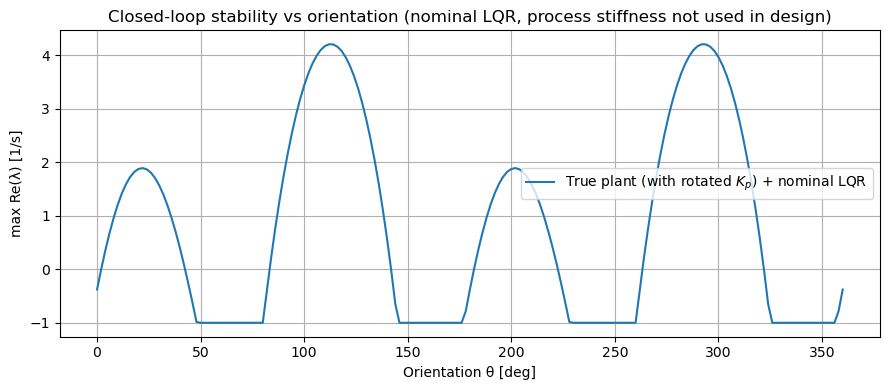

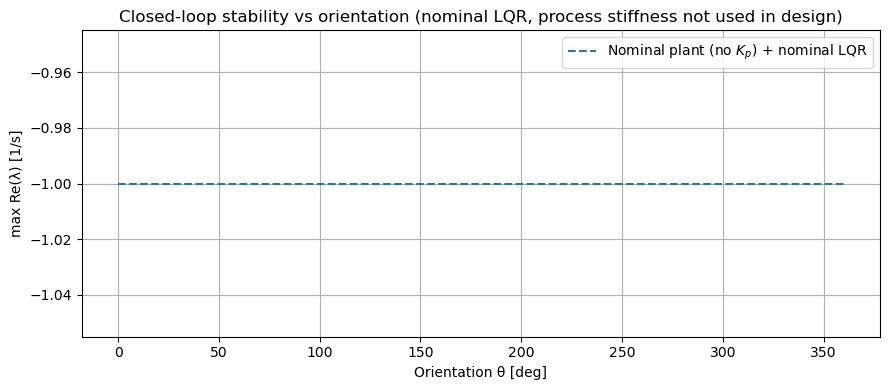

Worst θ = 112 deg | max Re = 4.205847548282882


In [50]:
theta_deg = np.arange(0, 360+2, 2)
theta_rad = np.deg2rad(theta_deg)

max_real_nom = []     # nominal CL (no Kp)
max_real_true = []    # true CL (Kp included), same K_nom

# state: [x, xhat, xdot, xhatdot]
xmax   = 5e-3     # m
xdmax  = 1e-3     # m/s
xhat   = 1e-7     # m
xhatd  = 1e-3     # m/s
umax   = 3000.0   # N (force command)

# LQR weights
Q = np.zeros((8,8))
Q[0:2,0:2] = (1/xmax**2)*np.eye(2)   #x
Q[2:4,2:4] = (1/xdmax**2)*np.eye(2)  #xdot
Q[4:6,4:6] = (1/xhat**2)*np.eye(2)   #p
Q[6:8,6:8] = (1/xhatd**2)*np.eye(2)  #pdot
R = (1/umax**2)*np.eye(2)


Q_axis = np.diag([1e2, 1e8, 1.0, 1e4])
Q = np.block([[Q_axis, np.zeros((4,4))],
              [np.zeros((4,4)), Q_axis]])

# Build model and Controller 
A_nom, Bu = build_absolute_actuated_model(M, C, K, M_micro, nu)
K_lqr_nom, P_nom = lqr(A_nom, Bu, Q, R)

print("K_lqr_nom shape:", K_lqr_nom.shape)

# --- closed-loop stability check ---
Acl_nom = A_nom - Bu @ K_lqr_nom
eig_nom = np.linalg.eigvals(Acl_nom)
max_nom = np.max(eig_nom.real)
print("max Re(lambda_cl) =", max_nom)

for th in theta_rad:
    Kp_rot = rotate_Kp(K_p, th)

    # A_true includes process stiffness absorbed
    A_true, _, _, _, _ = build_absolute_model_wProcess(M, C, K, M_micro, nu, Kp=Kp_rot)

    Acl_true = A_true - Bu @ K_lqr_nom
    eig_true = np.linalg.eigvals(Acl_true)

    max_real_nom.append(max_nom)
    max_real_true.append(np.max(eig_true.real))

max_real_nom = np.array(max_real_nom)
max_real_true = np.array(max_real_true)



plt.figure(figsize=(9,4))
plt.plot(theta_deg, max_real_true, label="True plant (with rotated $K_p$) + nominal LQR")
# plt.plot(theta_deg, max_real_nom, "--", label="Nominal plant (no $K_p$) + nominal LQR")
# plt.axhline(0, linestyle="--")
plt.xlabel("Orientation θ [deg]")
plt.ylabel("max Re(λ) [1/s]")
plt.title("Closed-loop stability vs orientation (nominal LQR, process stiffness not used in design)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
# plt.plot(theta_deg, max_real_true, label="True plant (with rotated $K_p$) + nominal LQR")
plt.plot(theta_deg, max_real_nom, "--", label="Nominal plant (no $K_p$) + nominal LQR")
# plt.axhline(0, linestyle="--")
plt.xlabel("Orientation θ [deg]")
plt.ylabel("max Re(λ) [1/s]")
plt.title("Closed-loop stability vs orientation (nominal LQR, process stiffness not used in design)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: show worst-case orientation
idx = int(np.argmax(max_real_true))
print("Worst θ =", theta_deg[idx], "deg | max Re =", max_real_true[idx])

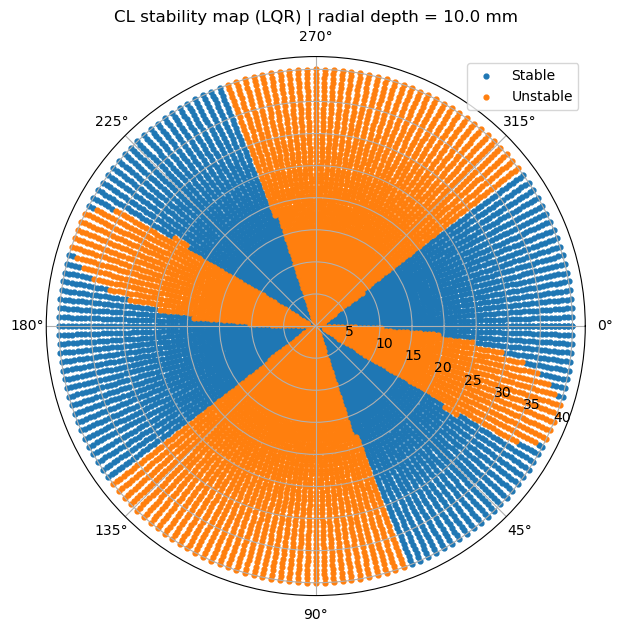

In [51]:
# ----- grid -----
theta_deg = np.arange(0, 360+2, 2)
theta_rad = np.deg2rad(theta_deg)

a_max = 40.0
a_depth_vals = np.linspace(0.1, a_max, 60)   # mm
max_real_map = np.zeros((len(a_depth_vals), len(theta_rad)))

# ----- LQR design on nominal (NO process stiffness) -----
A_nom, Bu = build_absolute_actuated_model(M, C, K, M_micro, nu)

# your Q/R (keep exactly what you like)
Q_axis = np.diag([1e2, 1e8, 1.0, 1e4])
Q = np.block([[Q_axis, np.zeros((4,4))],
              [np.zeros((4,4)), Q_axis]])
R = (1/umax**2)*np.eye(2)

K_lqr_nom, _ = lqr(A_nom, Bu, Q, R)


for ia, a_depth in enumerate(a_depth_vals):

    # entry/exit angles for downmilling at this radial depth
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(radial_depth, D)

    # base (unrotated) process stiffness at this depth (from cutting model)
    Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth,          # mm (as your cutting model expects)
        b_radial=radial_depth,    # mm
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )

    Kp_base = Kg * 1e3   # N/m  (keep your scaling convention)

    for it, th in enumerate(theta_rad):

        Kp_rot = rotate_Kp(Kp_base, th)

        # build true plant with absorbed process stiffness
        A_true, _, _, _, _ = build_absolute_model_wProcess(
            M, C, K, M_micro, nu, Kp=Kp_rot
        )

        # closed-loop matrix
        Acl = A_true - Bu @ K_lqr_nom

        eigvals = np.linalg.eigvals(Acl)
        max_real_map[ia, it] = np.max(eigvals.real)
        
theta_step = 1
depth_step = 1

theta_sub = theta_rad[::theta_step]
depth_sub = a_depth_vals[::depth_step]

stable_theta, stable_r = [], []
unstable_theta, unstable_r = [], []

for i_d, a_depth in enumerate(depth_sub):
    for i_t, th in enumerate(theta_sub):

        orig_d = i_d * depth_step
        orig_t = i_t * theta_step

        val = max_real_map[orig_d, orig_t]

        if val < 0:
            stable_theta.append(th)
            stable_r.append(a_depth)
        else:
            unstable_theta.append(th)
            unstable_r.append(a_depth)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

ax.scatter(stable_theta, stable_r, s=12, label="Stable")
ax.scatter(unstable_theta, unstable_r, s=12, label="Unstable")

ax.set_title(f"CL stability map (LQR) | radial depth = {radial_depth:.1f} mm")
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)
ax.legend(loc="upper right")
plt.show()



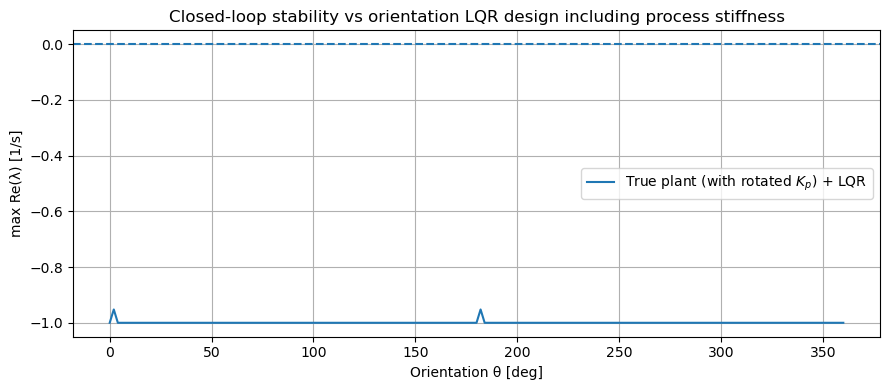

Worst θ = 2 deg | max Re = -0.9521970857685101


In [52]:
theta_deg = np.arange(0, 360+2, 2)
theta_rad = np.deg2rad(theta_deg)

max_real_true = []    # true CL (Kp included), same K_nom



for th in theta_rad:
    Kp_rot = rotate_Kp(K_p, th)
    A_true, _, _, _, _ = build_absolute_model_wProcess(M, C, K, M_micro, nu, Kp=Kp_rot)
    K_lqr_true, P_true = lqr(A_true, Bu, Q, R)
    
    Acl_true = A_true - Bu @ K_lqr_true
    eig_true = np.linalg.eigvals(Acl_true)
    max_real_true.append(np.max(eig_true.real))

max_real_true = np.array(max_real_true)



plt.figure(figsize=(9,4))
plt.plot(theta_deg, max_real_true, label="True plant (with rotated $K_p$) + LQR")
plt.axhline(0, linestyle="--")
plt.xlabel("Orientation θ [deg]")
plt.ylabel("max Re(λ) [1/s]")
plt.title("Closed-loop stability vs orientation LQR design including process stiffness")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

idx = int(np.argmax(max_real_true))
print("Worst θ =", theta_deg[idx], "deg | max Re =", max_real_true[idx])


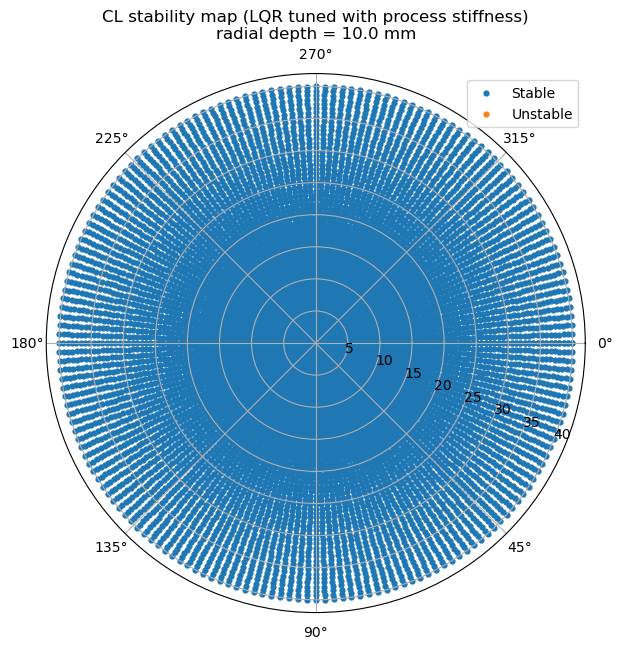

In [53]:
theta_deg = np.arange(0, 360+2, 2)
theta_rad = np.deg2rad(theta_deg)

a_max = 40.0
a_depth_vals = np.linspace(0.1, a_max, 60)   # mm

max_real_map = np.zeros((len(a_depth_vals), len(theta_rad)))

# Bu does NOT depend on Kp → compute once
A_tmp, Bu = build_absolute_actuated_model(M, C, K, M_micro, nu)

for ia, a_depth in enumerate(a_depth_vals):

    # cutting engagement geometry
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(radial_depth, D)

    # process stiffness at this axial depth
    Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth,
        b_radial=radial_depth,
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )

    Kp_base = Kg * 1e3   # N/m

    for it, th in enumerate(theta_rad):

        # rotate stiffness
        Kp_rot = rotate_Kp(Kp_base, th)

        # plant INCLUDING process stiffness
        A_true, _, _, _, _ = build_absolute_model_wProcess(
            M, C, K, M_micro, nu, Kp=Kp_rot
        )

        # ---- LQR tuned on THIS plant ----
        K_lqr_true, _ = lqr(A_true, Bu, Q, R)

        # closed-loop matrix
        Acl_true = A_true - Bu @ K_lqr_true

        eigvals = np.linalg.eigvals(Acl_true)
        max_real_map[ia, it] = np.max(eigvals.real)

stable_theta, stable_r = [], []
unstable_theta, unstable_r = [], []

for ia, a_depth in enumerate(a_depth_vals):
    for it, th in enumerate(theta_rad):

        if max_real_map[ia, it] < 0:
            stable_theta.append(th)
            stable_r.append(a_depth)
        else:
            unstable_theta.append(th)
            unstable_r.append(a_depth)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

ax.scatter(stable_theta, stable_r, s=12, label="Stable")
ax.scatter(unstable_theta, unstable_r, s=12, label="Unstable")

ax.set_title(
    f"CL stability map (LQR tuned with process stiffness)\n"
    f"radial depth = {radial_depth:.1f} mm"
)

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)
ax.legend(loc="upper right")
plt.show()



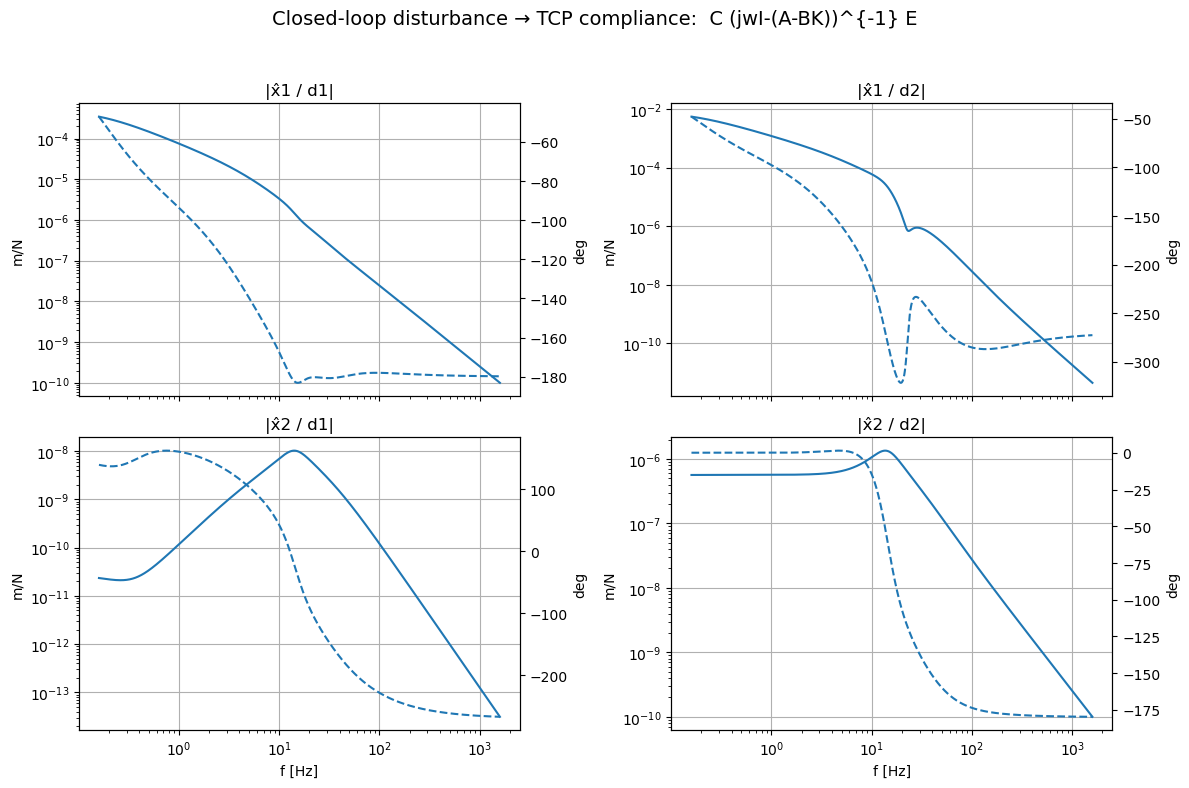

In [54]:
# Output matrix: y = xhat (states 2:4)
C_y = np.zeros((2,8))
C_y[:, 2:4] = np.eye(2)

# Disturbance injection: d (N) applied on TCP/micro
E = np.zeros((8,2))
E[6:8, :] = np.linalg.inv(M_micro)

def Gyd_jw(Acl, E, C_y, w):
    n = Acl.shape[0]
    I = np.eye(n)
    Gjw = np.zeros((len(w), C_y.shape[0], E.shape[1]), dtype=complex)
    for k, wi in enumerate(w):
        X = np.linalg.solve(1j*wi*I - Acl, E)   # (jwI - Acl)^-1 E
        Gjw[k] = C_y @ X
    return Gjw

w = np.logspace(0, 4, 2000)
f = w / (2*np.pi)
Gjw = Gyd_jw(Acl_true, E, C_y, w)  # shape (N,2,2)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):
    ax = axes[idx]
    Hij = Gjw[:, i, j]
    mag = np.abs(Hij)               # m/N
    phase = np.unwrap(np.angle(Hij))*180/np.pi

    # ax.semilogx(w, mag)
    ax.loglog(f, mag)
    ax.set_title(f"|x̂{i+1} / d{j+1}|")
    ax.set_ylabel("m/N")
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.semilogx(f, phase, linestyle="--")
    ax2.set_ylabel("deg")

for ax in axes[-2:]:
    ax.set_xlabel("f [Hz]")

fig.suptitle("Closed-loop disturbance → TCP compliance:  C (jwI-(A-BK))^{-1} E", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


Worst θ = 2 deg | max Re = -0.9521970857685101


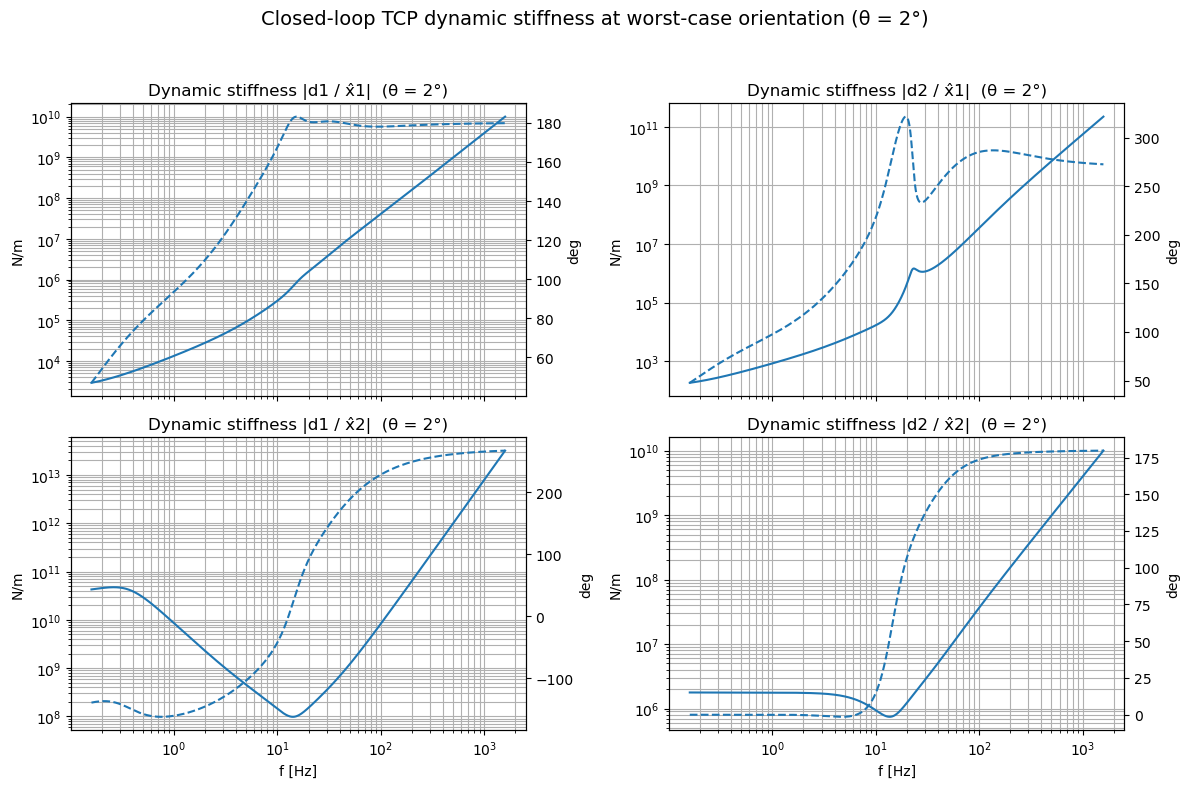

In [55]:

idx = int(np.argmax(max_real_true))
print("Worst θ =", theta_deg[idx], "deg | max Re =", max_real_true[idx])
theta_worst_deg = theta_deg[idx]
# Output matrix: y = xhat (states 2:4)
C_y = np.zeros((2,8))
C_y[:, 2:4] = np.eye(2)

# Disturbance injection: d (N) applied on TCP/micro
E = np.zeros((8,2))
E[6:8, :] = np.linalg.inv(M_micro)

def Gyd_jw(Acl, E, C_y, w):
    n = Acl.shape[0]
    I = np.eye(n)
    Gjw = np.zeros((len(w), C_y.shape[0], E.shape[1]), dtype=complex)
    for k, wi in enumerate(w):
        X = np.linalg.solve(1j*wi*I - Acl, E)   # (jwI - Acl)^-1 E
        Gjw[k] = C_y @ X
    return Gjw

w = np.logspace(0, 4, 2000)
f = w / (2*np.pi)

Gjw = Gyd_jw(Acl_true, E, C_y, w)  # compliance xhat/d, shape (N,2,2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

eps = 1e-30  # avoid divide-by-zero in inverse

for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):
    ax = axes[idx]

    Hij = Gjw[:, i, j]                 # compliance [m/N]
    comp_mag = np.abs(Hij)
    stiff_mag = 1.0 / np.maximum(comp_mag, eps)   # dynamic stiffness [N/m]

    phase_comp = np.unwrap(np.angle(Hij)) * 180/np.pi
    phase_stiff = -phase_comp  # since 1/H -> phase flips sign

    ax.loglog(f, stiff_mag)
    ax.set_title(f"Dynamic stiffness |d{j+1} / x̂{i+1}|  (θ = {theta_worst_deg}°)")
    ax.set_ylabel("N/m")
    ax.grid(True, which="both")

    ax2 = ax.twinx()
    ax2.semilogx(f, phase_stiff, linestyle="--")
    ax2.set_ylabel("deg")

for ax in axes[-2:]:
    ax.set_xlabel("f [Hz]")

fig.suptitle(f"Closed-loop TCP dynamic stiffness at worst-case orientation (θ = {theta_worst_deg}°)",
             fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


Worst θ = 2 deg | max Re = -0.9521970857685101
Best  θ = 24 deg | max Re = -1.000000001929886


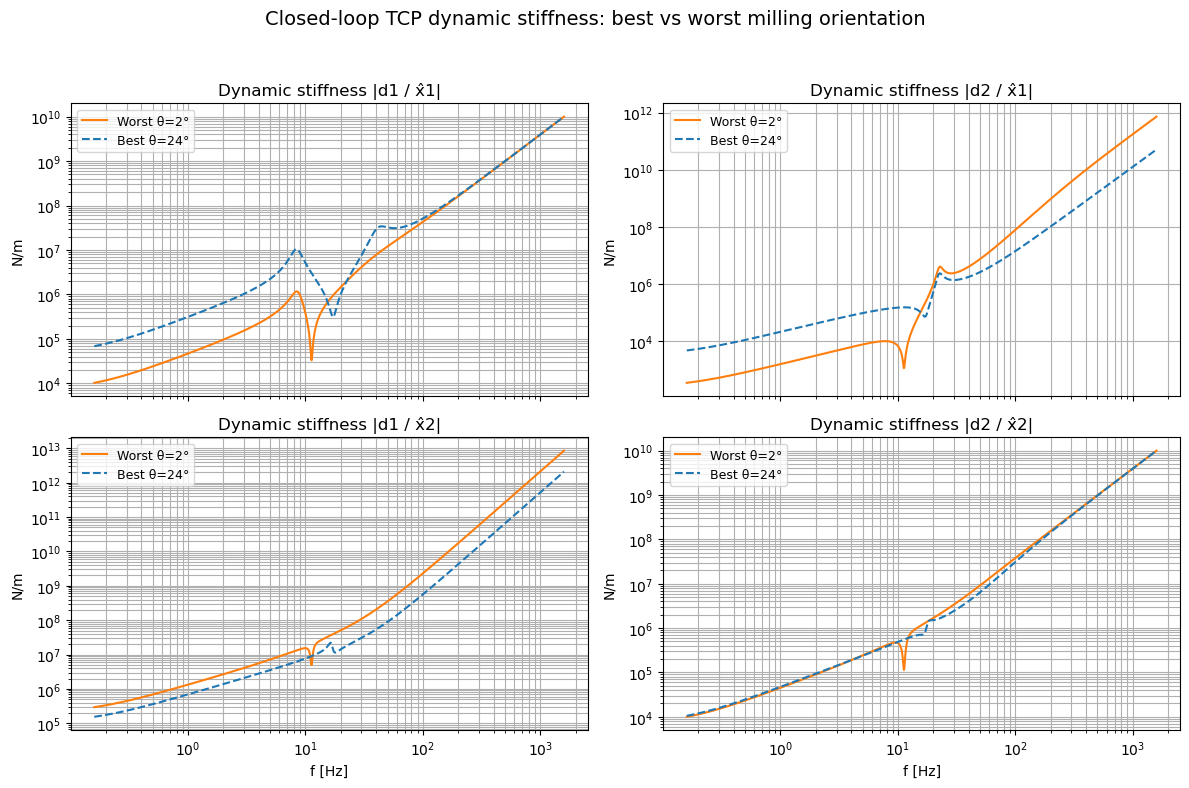

In [56]:
# --- identify worst and best orientations (by max_real_true) ---
idx_worst = int(np.argmax(max_real_true))
idx_best  = int(np.argmin(max_real_true))

theta_worst_deg = theta_deg[idx_worst]
theta_best_deg  = theta_deg[idx_best]

print("Worst θ =", theta_worst_deg, "deg | max Re =", max_real_true[idx_worst])
print("Best  θ =", theta_best_deg,  "deg | max Re =", max_real_true[idx_best])

# --- build Acl for worst and best by re-creating the plant and LQR at each theta ---
def build_Acl_for_theta(theta_deg_val):
    th = np.deg2rad(theta_deg_val)
    Kp_rot = rotate_Kp(K_p, th)
    A_theta, _, _, _, _ = build_absolute_model_wProcess(M, C, K, M_micro, nu, Kp=Kp_rot)
    K_theta, _ = lqr(A_theta, Bu, Q, R)
    return A_theta - Bu @ K_theta

Acl_worst = build_Acl_for_theta(theta_worst_deg)
Acl_best  = build_Acl_for_theta(theta_best_deg)

# Output matrix: y = xhat (states 2:4)
C_y = np.zeros((2,8))
C_y[:, 2:4] = np.eye(2)

# Disturbance injection: d (N) applied on TCP/micro
E = np.zeros((8,2))
E[6:8, :] = np.linalg.inv(M_micro)

def Gyd_jw(Acl, E, C_y, w):
    n = Acl.shape[0]
    I = np.eye(n)
    Gjw = np.zeros((len(w), C_y.shape[0], E.shape[1]), dtype=complex)
    for k, wi in enumerate(w):
        X = np.linalg.solve(1j*wi*I - Acl, E)
        Gjw[k] = C_y @ X
    return Gjw

w = np.logspace(0, 4, 2000)
f = w / (2*np.pi)

# compliance for worst/best
Gjw_worst = Gyd_jw(Acl_worst, E, C_y, w)
Gjw_best  = Gyd_jw(Acl_best,  E, C_y, w)

# --- plot dynamic stiffness for both ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
eps = 1e-30

for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):
    ax = axes[idx]

    # worst
    H_w = Gjw_worst[:, i, j]
    comp_w = np.abs(H_w)
    stiff_w = 1.0 / np.maximum(comp_w, eps)
    phase_w = -np.unwrap(np.angle(H_w)) * 180/np.pi

    # best
    H_b = Gjw_best[:, i, j]
    comp_b = np.abs(H_b)
    stiff_b = 1.0 / np.maximum(comp_b, eps)
    phase_b = -np.unwrap(np.angle(H_b)) * 180/np.pi

    ax.loglog(f, stiff_w, label=f"Worst θ={theta_worst_deg}°", color="tab:orange")
    ax.loglog(f, stiff_b, linestyle="--", label=f"Best θ={theta_best_deg}°", color="tab:blue")
    ax.set_title(f"Dynamic stiffness |d{j+1} / x̂{i+1}|")
    ax.set_ylabel("N/m")
    ax.grid(True, which="both")
    ax.legend(fontsize=9)

    # ax2 = ax.twinx()
    # ax2.semilogx(f, phase_w, label="phase (worst)")
    # ax2.semilogx(f, phase_b, linestyle="--", label="phase (best)")
    # ax2.set_ylabel("deg")

for ax in axes[-2:]:
    ax.set_xlabel("f [Hz]")

fig.suptitle("Closed-loop TCP dynamic stiffness: best vs worst milling orientation", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


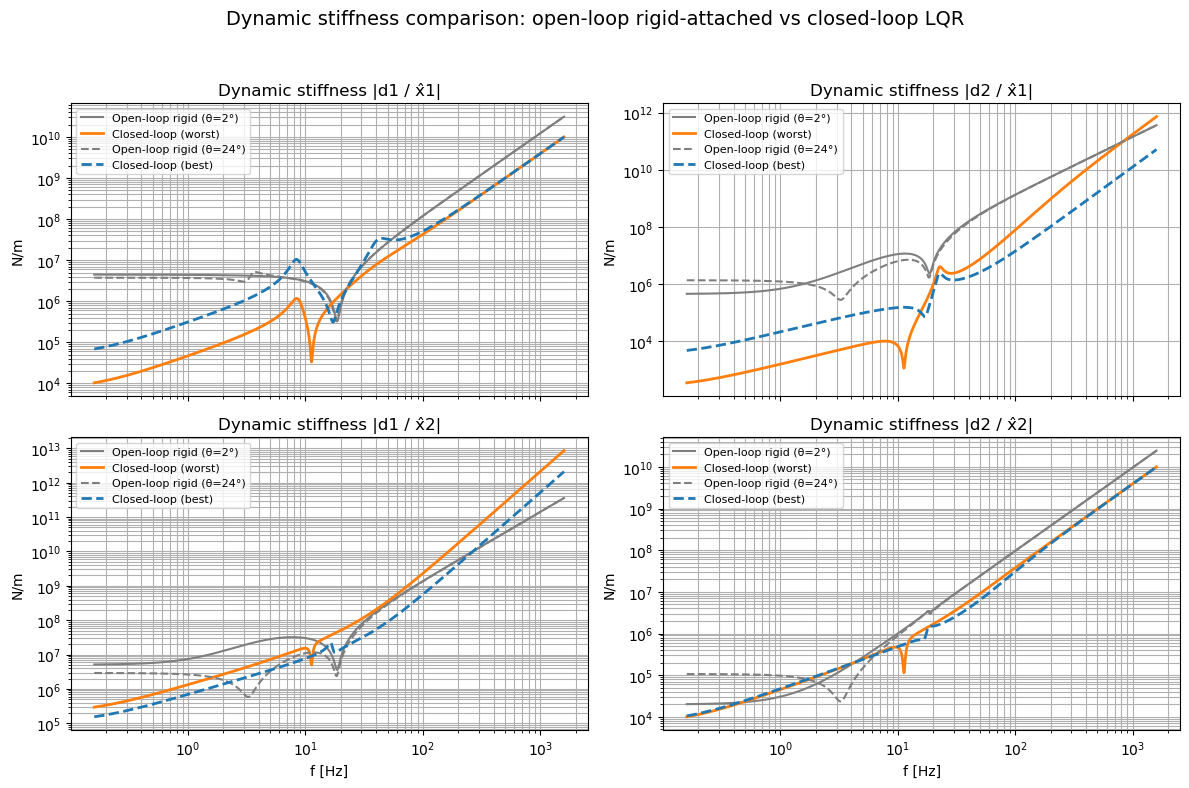

In [57]:
def rigid_attached_compliance_jw(M, C, K_eff, w):
    """
    Compliance for rigid attached mass model:
      x/d = ( -w^2 M + j w C + K_eff )^{-1}
    Returns array (N,2,2)
    """
    Gjw = np.zeros((len(w), 2, 2), dtype=complex)
    for k, wi in enumerate(w):
        D = (-wi**2)*M + 1j*wi*C + K_eff
        Gjw[k] = np.linalg.inv(D)
    return Gjw

# total mass for rigid attachment
M_tot = M + M_micro

# pick best/worst K_eff (same convention you used: K_eff = K - Kp_rot)
Kp_worst = rotate_Kp(K_p, np.deg2rad(theta_worst_deg))
Kp_best  = rotate_Kp(K_p, np.deg2rad(theta_best_deg))

Keff_worst = K +Kp_worst
Keff_best  = K +Kp_best

G_rigid_worst = rigid_attached_compliance_jw(M_tot, C, Keff_worst, w)  # x/d
G_rigid_best  = rigid_attached_compliance_jw(M_tot, C, Keff_best,  w)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
eps = 1e-30

for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):
    ax = axes[idx]

    # Closed-loop stiffness (from your state-space compliance)
    Hcl_w = Gjw_worst[:, i, j]  # xhat/d
    Hcl_b = Gjw_best[:,  i, j]

    stiff_cl_w = 1.0 / np.maximum(np.abs(Hcl_w), eps)
    stiff_cl_b = 1.0 / np.maximum(np.abs(Hcl_b), eps)

    # Open-loop rigid-attached stiffness (x/d, but x == xhat in rigid attachment)
    Hol_w = G_rigid_worst[:, i, j]
    Hol_b = G_rigid_best[:,  i, j]

    stiff_ol_w = 1.0 / np.maximum(np.abs(Hol_w), eps)
    stiff_ol_b = 1.0 / np.maximum(np.abs(Hol_b), eps)

    ax.loglog(f, stiff_ol_w, color="tab:gray", linestyle="-",  linewidth=1.5,
              label=f"Open-loop rigid (θ={theta_worst_deg}°)")
    ax.loglog(f, stiff_cl_w, color="tab:orange", linestyle="-", linewidth=2.0,
              label="Closed-loop (worst)")

    ax.loglog(f, stiff_ol_b, color="tab:gray", linestyle="--", linewidth=1.5,
              label=f"Open-loop rigid (θ={theta_best_deg}°)")
    ax.loglog(f, stiff_cl_b, color="tab:blue", linestyle="--", linewidth=2.0,
              label="Closed-loop (best)")

    ax.set_title(f"Dynamic stiffness |d{j+1} / x̂{i+1}|")
    ax.set_ylabel("N/m")
    ax.grid(True, which="both")
    ax.legend(fontsize=8)

for ax in axes[-2:]:
    ax.set_xlabel("f [Hz]")

fig.suptitle("Dynamic stiffness comparison: open-loop rigid-attached vs closed-loop LQR", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [58]:
from scipy.linalg import solve_continuous_are, block_diag
import numpy as np


def lqr(A, B, Q, R):
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)
    return K, P

def lqi_single_state(A, B, Qx, R, idx_xhat, qi=1e2):
    """
    Continuous-time LQI with ONE integrator:
        xI_dot = - x_hat

    idx_xhat : index of state to integrate
    qi       : integral-state weight (tuning knob)
    """

    n = A.shape[0]

    # Select the state to integrate
    H = np.zeros((1, n))
    H[0, idx_xhat] = 1.0

    # Augmented system:
    # [ xdot ] = [ A   0 ] [ x  ] + [ B ] u
    # [ xI_dot]= [ -H  0 ] [ xI ]   [ 0 ]
    A_aug = np.block([
        [A,              np.zeros((n,1))],
        [-H,             np.zeros((1,1))]
    ])

    B_aug = np.vstack([
        B,
        np.zeros((1, B.shape[1]))
    ])

    # Augmented cost
    Qi = np.array([[qi]])
    Q_aug = block_diag(Qx, Qi)

    # LQR on augmented system
    K_aug, _ = lqr(A_aug, B_aug, Q_aug, R)

    # Split gains
    Kx = K_aug[:, :n]
    Ki = K_aug[:, n:]

    return Kx, Ki, K_aug, A_aug, B_aug

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
idx_xhat = 2   # <-- set to the index of the state you want to track to zero
qi = 1e4       # <-- integrator penalty (tune)

Qx = Q         # your existing 8x8 state penalty

# ------------------------------------------------------------
# MAIN MAP COMPUTATION
# ------------------------------------------------------------
for ia, a_depth in enumerate(a_depth_vals):

    # cutting engagement geometry (depends on depth if your model does)
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(radial_depth, D)

    # process stiffness at this axial depth
    Kg = zero_order_dF(
        c=fz,
        a_axial=a_depth,
        b_radial=radial_depth,
        D=D,
        N_teeth=N_teeth,
        phi_st=phi_st,
        phi_ex=phi_ex,
        n_hat=np.array([0.0, 1.0]),
        Ktc=Ktc,
        Krc=Krc
    )
    Kp_base = Kg * 1e3  # N/m

    for it, th in enumerate(theta_rad):

        # rotate stiffness
        Kp_rot = rotate_Kp(Kp_base, th)

        # plant INCLUDING process stiffness
        A_true, _, _, _, _ = build_absolute_model_wProcess(
            M, C, K, M_micro, nu, Kp=Kp_rot
        )

        # ---- LQI tuned on THIS plant ----
        Kx, Ki, K_aug, A_aug, B_aug = lqi_single_state(
            A_true, Bu, Qx, R, idx_xhat, qi
        )

        # closed-loop matrix INCLUDING integrator mode
        Acl_aug = A_aug - B_aug @ K_aug

        eigvals = np.linalg.eigvals(Acl_aug)
        max_real_map[ia, it] = np.max(eigvals.real)


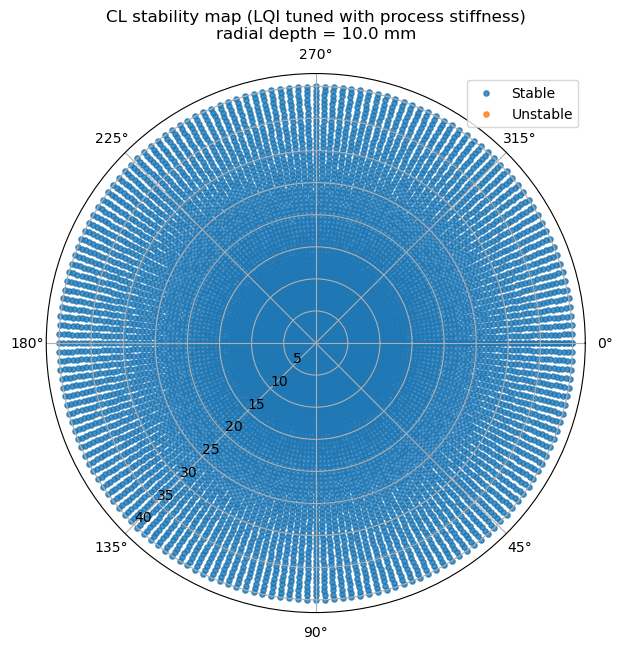

In [59]:
stable_theta, stable_r = [], []
unstable_theta, unstable_r = [], []

for ia, a_depth in enumerate(a_depth_vals):
    for it, th in enumerate(theta_rad):

        if max_real_map[ia, it] < 0:
            stable_theta.append(th)
            stable_r.append(a_depth)
        else:
            unstable_theta.append(th)
            unstable_r.append(a_depth)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

# Plot stable points
ax.scatter(
    stable_theta,
    stable_r,
    s=14,
    alpha=0.8,
    label="Stable"
)

# Plot unstable points
ax.scatter(
    unstable_theta,
    unstable_r,
    s=14,
    alpha=0.8,
    label="Unstable"
)

ax.set_title(
    "CL stability map (LQI tuned with process stiffness)\n"
    f"radial depth = {radial_depth:.1f} mm"
)

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

# Optional: nicer radial grid
ax.set_rlabel_position(135)

ax.legend(loc="upper right")
plt.show()


Worst θ = 2 deg | max Re = -0.9521970857685101
Best  θ = 24 deg | max Re = -1.000000001929886


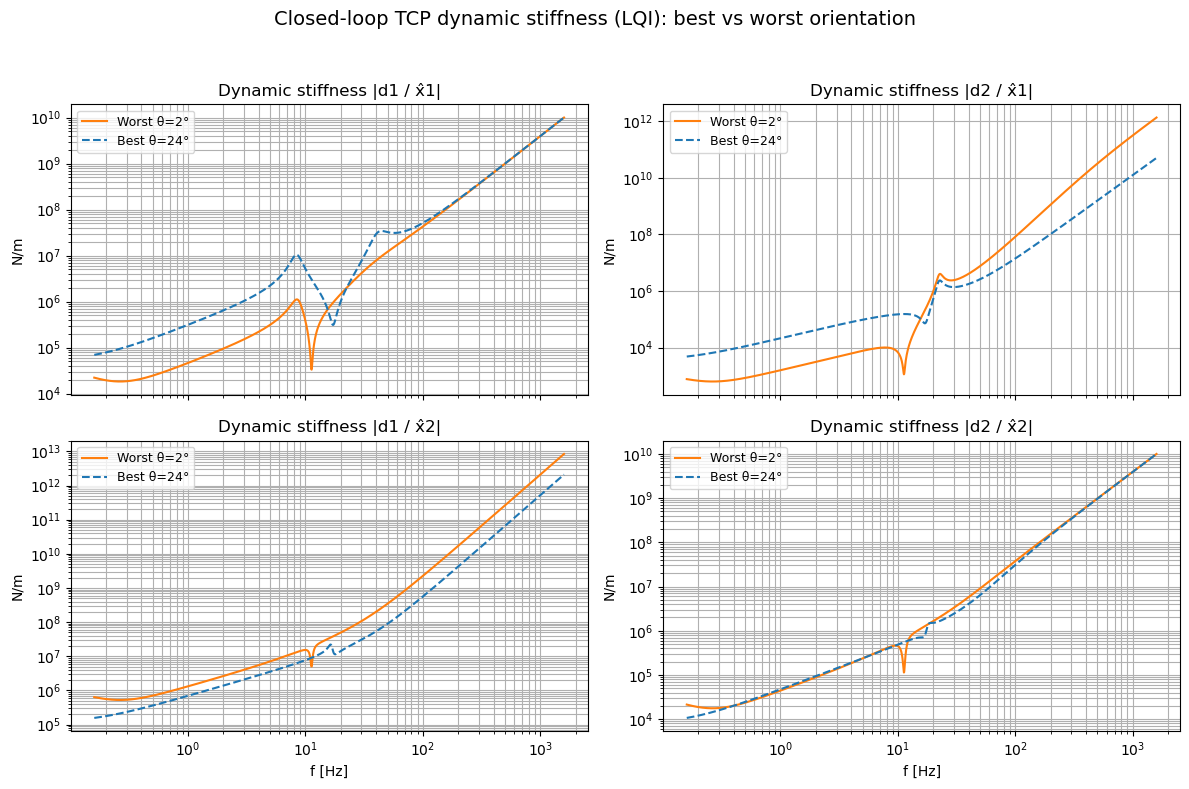

In [60]:
def build_Acl_for_theta_LQI(theta_deg_val, idx_xhat=2, qi=1e2):
    th = np.deg2rad(theta_deg_val)

    # rotate process stiffness
    Kp_rot = rotate_Kp(K_p, th)

    # plant INCLUDING process stiffness
    A_theta, _, G_a, _, _ = build_absolute_model_wProcess(
        M, C, K, M_micro, nu, Kp=Kp_rot
    )

    # ---- LQI design (integrating x_hat only) ----
    Kx, Ki, K_aug, A_aug, B_aug = lqi_single_state(
        A_theta, Bu, Q, R, idx_xhat, qi
    )

    # augmented closed-loop matrix
    Acl_aug = A_aug - B_aug @ K_aug

    # augmented disturbance matrix:
    # disturbance affects physical states only
    E_aug = np.vstack([
        G_a,
        np.zeros((1, G_a.shape[1]))   # integrator not directly disturbed
    ])

    return Acl_aug, E_aug

idx_worst = int(np.argmax(max_real_true))
idx_best  = int(np.argmin(max_real_true))

theta_worst_deg = theta_deg[idx_worst]
theta_best_deg  = theta_deg[idx_best]

print("Worst θ =", theta_worst_deg, "deg | max Re =", max_real_true[idx_worst])
print("Best  θ =", theta_best_deg,  "deg | max Re =", max_real_true[idx_best])

Acl_worst, E_worst = build_Acl_for_theta_LQI(theta_worst_deg)
Acl_best,  E_best  = build_Acl_for_theta_LQI(theta_best_deg)

n_aug = Acl_worst.shape[0]   # 9 if original was 8

C_y = np.zeros((2, n_aug))
C_y[:, 2:4] = np.eye(2)

def Gyd_jw(Acl, E, C_y, w):
    n = Acl.shape[0]
    I = np.eye(n)
    Gjw = np.zeros((len(w), C_y.shape[0], E.shape[1]), dtype=complex)

    for k, wi in enumerate(w):
        X = np.linalg.solve(1j*wi*I - Acl, E)
        Gjw[k] = C_y @ X

    return Gjw

w = np.logspace(0, 4, 2000)
f = w / (2*np.pi)

Gjw_worst = Gyd_jw(Acl_worst, E_worst, C_y, w)
Gjw_best  = Gyd_jw(Acl_best,  E_best,  C_y, w)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
eps = 1e-30

for idx, (i, j) in enumerate([(0,0), (0,1), (1,0), (1,1)]):

    ax = axes[idx]

    # worst
    H_w = Gjw_worst[:, i, j]
    stiff_w = 1.0 / np.maximum(np.abs(H_w), eps)

    # best
    H_b = Gjw_best[:, i, j]
    stiff_b = 1.0 / np.maximum(np.abs(H_b), eps)

    ax.loglog(f, stiff_w, label=f"Worst θ={theta_worst_deg}°", color="tab:orange")
    ax.loglog(f, stiff_b, linestyle="--", label=f"Best θ={theta_best_deg}°", color="tab:blue")

    ax.set_title(f"Dynamic stiffness |d{j+1} / x̂{i+1}|")
    ax.set_ylabel("N/m")
    ax.grid(True, which="both")
    ax.legend(fontsize=9)

for ax in axes[-2:]:
    ax.set_xlabel("f [Hz]")

fig.suptitle("Closed-loop TCP dynamic stiffness (LQI): best vs worst orientation", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()